# IS362 Project 2

Leveraging Pandas to tidy data and extrapolate useful insights

# DataSet 1: Salary Survey

My first dataset is my own which includes salary information I will
- Tidy this data up for easier insights
- Leverage this tidy data to examine the relationship between education level and salary if any
- Build a bar chart showcasing this information

In [ ]:
# Import Modules

import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


ss = "salary_survey.csv"

if not os.path.exists(ss):
    url = "https://docs.google.com/spreadsheets/d/1IPS5dBSGtwYVbjsfbaMCYIWnOuRmJcbequohNxCyGVw/export?format=csv&gid=1625408792"
    surveys = pd.read_csv(url)
    surveys.to_csv(ss, index=False)
    print("Downloaded and saved locally")
else:
    surveys = pd.read_csv(ss)
    print("Loaded from local file")

# Print the top rows of the survey for initial investigation
surveys.head()

Loaded from local file


,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:",What is your annual salary?,"How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",What country do you work in?,"If you're in the U.S., what state do you work in?",What city do you work in?,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,What is your race? (Choose all that apply.)
0,4/27/2021 11:02,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


Now I will use Pandas to tidy up columns and provide insightful education data 

In [27]:
column_names = {
    'How old are you?': 'age',
    'What industry do you work in?': 'industry',
    'Job title': 'title',
    'What is your annual salary?': 'salary',
    'What country do you work in?': 'country',
    'How many years of professional work experience do you have in your field?': 'experience',
    'What is your highest level of education completed?': 'education',
    'What is your gender?': 'gender',
    'Please indicate the currency': 'currency'
}

education_order = [
    'High School',
    'Some college', 
    'College degree',
    "Master's degree",
    'Professional degree (MD, JD, etc.)',
    'PhD'
]

surveys = (pd.read_csv("salary_survey.csv")
    .rename(columns=column_names)
    .dropna(subset=["salary", "education"])
    [["age", "industry", "title", "salary", "education", "gender", "currency"]]
    .assign(salary=lambda x: pd.to_numeric(
        x["salary"].str.replace(",", "").str.strip(), errors="coerce"))
    .dropna(subset=["salary"])
    .query("currency == 'USD'")
    .query("10000 <= salary <= 500000")
)

print(surveys.shape)
print(surveys["education"].value_counts())

(23151, 7)
education
College degree                        11325
Master's degree                        7505
Some college                           1644
Professional degree (MD, JD, etc.)     1131
PhD                                    1127
High School                             419
Name: count, dtype: int64


Here I will correlate education level to salary. Doing this will help me in my final step of creating a bar chart to provide a visual representation of this information

In [28]:
# Calculate mean salary by education level
edu_salary = (surveys
    .groupby("education")["salary"]
    .mean()
    .reindex(education_order)  # apply logical order
    .round(2)
)

print(edu_salary)

education
High School                            73075.51
Some college                           76456.43
College degree                         86097.73
Master's degree                        91282.34
Professional degree (MD, JD, etc.)    136436.24
PhD                                   108398.37
Name: salary, dtype: float64


Now I will create a bar chart to visualize this data and provide actionable information regarding the affect of education level on salary

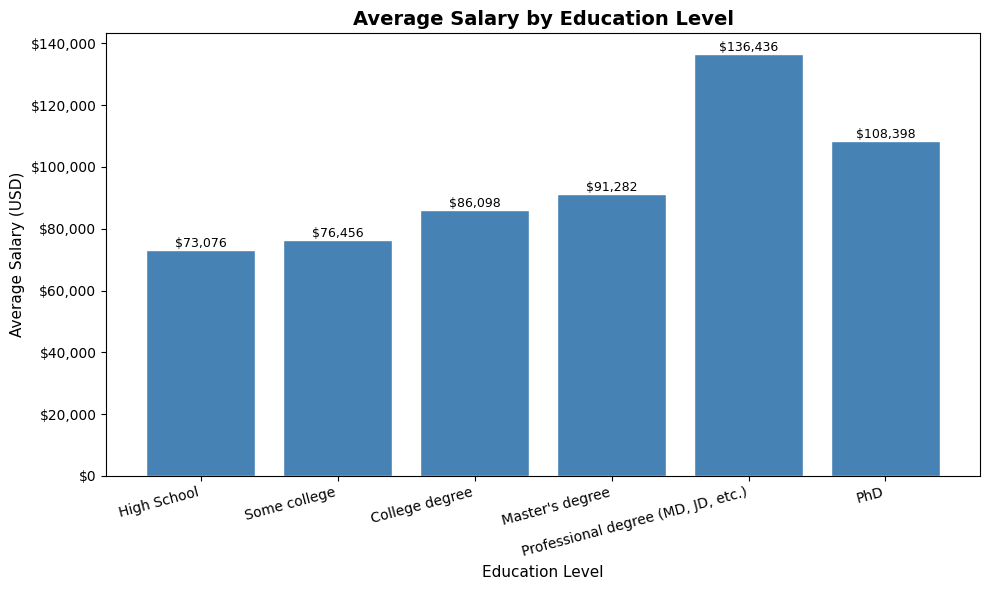

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(education_order, edu_salary.values, color="steelblue", edgecolor="white")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}',
            ha='center', va='bottom', fontsize=9)

ax.set_title("Average Salary by Education Level", fontsize=14, fontweight="bold")
ax.set_xlabel("Education Level", fontsize=11)
ax.set_ylabel("Average Salary (USD)", fontsize=11)
ax.set_xticks(range(len(education_order)))
ax.set_xticklabels(education_order, rotation=15, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

Looking at this simple bar chart we can observe a clear corrolation between education level and salary with salary steadily increasing alongside education attainment. There is an oberservable drop between professional degree and PhD ~ $28,000 which could be attributed to profession.

Let's perform a quick query to confirm that.

In [30]:
advanced = surveys[surveys["education"].isin([
    "Professional degree (MD, JD, etc.)",
    "PhD"
])]

print(advanced.shape)

print(advanced.groupby("education")["title"]
      .value_counts()
      .groupby(level=0)
      .head(10))

(2258, 7)
education                           title                    
PhD                                 Assistant Professor          57
                                    Associate Professor          32
                                    Professor                    22
                                    Scientist                    19
                                    Assistant Professor          14
                                    Director                     14
                                    Research Scientist           14
                                    Lecturer                     11
                                    Assistant professor          11
                                    Data Scientist               11
Professional degree (MD, JD, etc.)  Attorney                     85
                                    Associate Attorney           53
                                    Associate                    40
                                    Partner 

Looking at the top 10 most common job titles for each group we see PhD holders skew toward the eduction field and Professional degree holders in various levels of the medical and law fields.

# DataSet 2: Ranking Video Games

Now I will use the dataset provided by Patrick Diaz to gain insight about two developers with a high number of sales Nintendo and Rockstar has had the most sales on the wii platform

First I will import the data and gain a broad perspective of the columns in the file

In [5]:
gs = "game_sales.csv"

if not os.path.exists(gs):
    url = "https://en.wikipedia.org/wiki/List_of_best-selling_video_games"
    tables = pd.read_html(url)
    games = tables[0]
    games.to_csv(gs, index=False)
    print("Downloaded and saved locally")
else:
    games = pd.read_csv(gs)
    print("Loaded from local file")

print(games.shape)
print(games.columns.tolist())


Loaded from local file
(52, 8)
['Rank', 'Title', 'Sales  (millions)', 'Series', 'Platform(s)', 'Release year', 'Developer(s)', 'Publisher(s)']


Now I will rename the columns for readability and tidying up issues in the file including inconsistant developer naming convention.

In [6]:
column_names = {
    'Rank': 'rank',
    'Title': 'title',
    'Sales  (millions)': 'sales',
    'Series': 'series',
    'Platform(s)': 'platform',
    'Release year': 'release_year',
    'Developer(s)': 'developer',
    'Publisher(s)': 'publisher'
}

games = (pd.read_csv(gs)
    .rename(columns=column_names)
    .assign(
        sales=lambda x: pd.to_numeric(x["sales"], errors="coerce"),
        release_year=lambda x: x["release_year"]
            .astype(str)
            .str.extract(r"(\d{4})")
            .astype(float),
        platform=lambda x: x["platform"].str.strip().str.lower(),
        developer=lambda x: x["developer"].str.strip().str.lower(),
        rank=lambda x: x["rank"].astype(str).str.extract(r"(\d+)").astype(float),
        title=lambda x: x["title"].str.replace(r"\[.*?\]", "", regex=True).str.strip()
    )
    .dropna(subset=["sales", "release_year"])
)

print(games.head())

   rank                  title  sales            series        platform  \
0   1.0                 Tetris  520.0               NaN  multi-platform   
1   1.0              Minecraft  350.0         Minecraft  multi-platform   
2   2.0     Grand Theft Auto V  225.0  Grand Theft Auto  multi-platform   
3   3.0             Wii Sports   82.9               Wii             wii   
4   4.0  Red Dead Redemption 2   82.0          Red Dead  multi-platform   

   release_year       developer       publisher  
0        1988.0         various         Various  
1        2011.0  mojang studios  Mojang Studios  
2        2013.0  rockstar north  Rockstar Games  
3        2006.0    nintendo ead        Nintendo  
4        2018.0  rockstar games  Rockstar Games  


Now I will combine and melt the data to assist me with creating a bar plot to visualize a sales comparison between Rockstar Games and Nintendo

In [44]:
wii = games[games["platform"] == "wii"]
print("Wii games:", wii.shape)
print(wii[["title", "developer", "sales"]])

# Step 2 — filter rockstar
rockstar = games[
    (games["developer"].isin(["rockstar north", "rockstar games"])) &
    (games["platform"] == "multi-platform")
]
print("Rockstar games:", rockstar.shape)
print(rockstar[["title", "developer", "sales"]])

# Step 3 — combine AFTER both are defined
combined = pd.concat([wii, rockstar])
print("Combined:", combined.shape)

# Step 4 — melt
combined_melted = pd.melt(
    combined,
    id_vars=["title", "developer"],
    value_vars=["sales"],
    var_name="metric",
    value_name="value"
)
print(combined_melted[["title", "developer", "value"]])

Wii games: (6, 8)
                        title     developer  sales
3                  Wii Sports  nintendo ead  82.90
16             Wii Fit / Plus  nintendo ead  43.80
23             Mario Kart Wii  nintendo ead  37.38
26          Wii Sports Resort  nintendo ead  33.14
28  New Super Mario Bros. Wii  nintendo ead  30.32
38                   Wii Play  nintendo ead  28.02
Rockstar games: (4, 8)
                            title       developer  sales
2              Grand Theft Auto V  rockstar north  225.0
4           Red Dead Redemption 2  rockstar games   82.0
40  Grand Theft Auto: San Andreas  rockstar north   27.5
51            Grand Theft Auto IV  rockstar north   25.0
Combined: (10, 8)
                           title       developer   value
0                     Wii Sports    nintendo ead   82.90
1                 Wii Fit / Plus    nintendo ead   43.80
2                 Mario Kart Wii    nintendo ead   37.38
3              Wii Sports Resort    nintendo ead   33.14
4      New Sup

Lastly I will create a barplot to visualize the

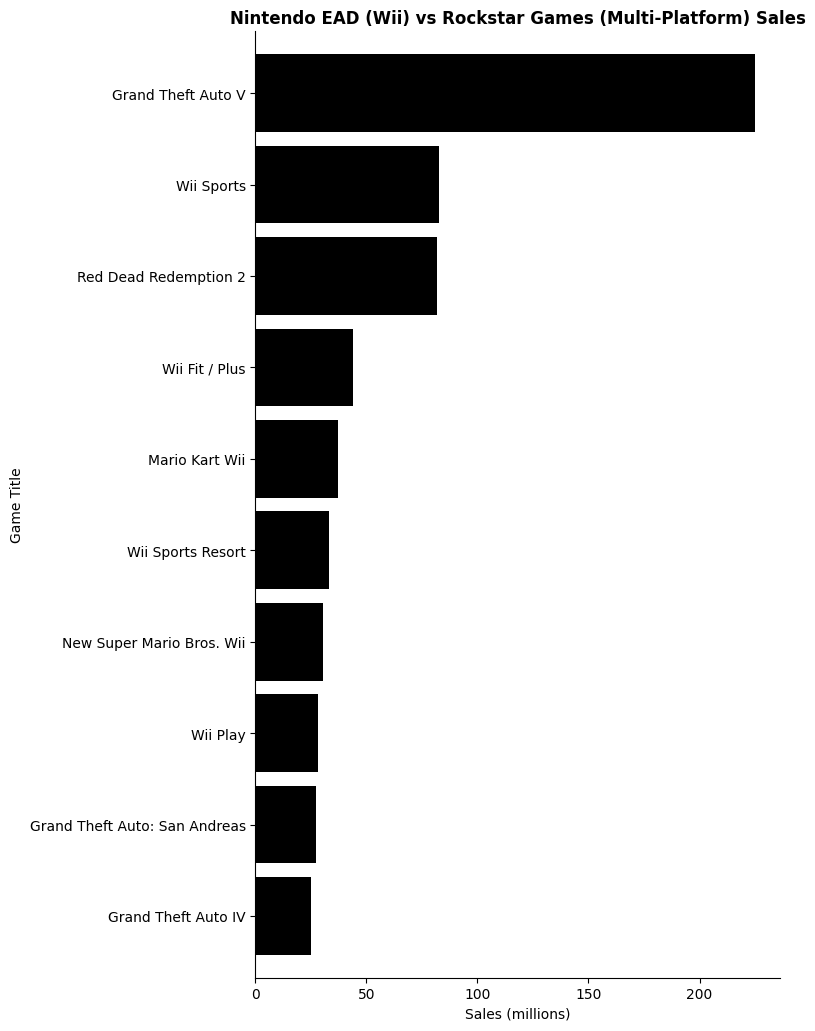

In [49]:
# Sort by sales value
combined_melted_sorted = combined_melted.sort_values("value")

# Plot
combined_melted_sorted.plot.barh(
    x="title",
    y="value",
    figsize=(8, 10),
    width=.85,
    color='k',
    legend=False
)

plt.tight_layout()
sns.despine()
plt.xlabel("Sales (millions)")
plt.ylabel("Game Title")
plt.title("Nintendo EAD (Wii) vs Rockstar Games (Multi-Platform) Sales",
          fontsize=12, fontweight="bold")
plt.show()

With this chart we can see the massive difference in sales for both Nintendo and Rockstar. We can also see how far ahead Grand Theft Auto V is in sales, with 225 million units sold, placing it first among Rockstar titles and far ahead of the other games in the dataset.

# Dataset 3 Box Office

Now I will use the dataset provided by Anas Khan on the top box office movies. 
- I will try to analyze the data and gain more insight between the relationships of the year, total gross, and average revenue for these movies

In [21]:
bo = "box_office.csv"

if not os.path.exists(bo):
    url = "https://www.boxofficemojo.com/year/"
    revenues = pd.read_html(url)
    revenues.to_csv(bo, index=False)
    print("Downloaded and saved locally")
else:
    revenues = pd.read_csv(bo)
    print("Loaded from local file")

# Print the top rows of the survey for initial investigation
revenues.head()

Loaded from local file


,Year,Total Gross,%� LY,Releases,Average,#1 Release
0,2026,"$1,154,994,634",-,163,"$7,085,856",Avatar: Fire and Ash
1,2025,"$8,655,387,700",1%,668,"$12,957,167",A Minecraft Movie
2,2024,"$8,571,249,443",-3.80%,677,"$12,660,634",Inside Out 2
3,2023,"$8,907,716,802",20.90%,592,"$15,046,818",Barbie
4,2022,"$7,369,914,732",64.40%,502,"$14,681,105",Top Gun: Maverick


Now that we have established a brief overview of the data with the top 5 grossing movies we will tidy the data. Renaming columns for easier understanding and standardizing the naming.

In [22]:
revenues = (pd.read_csv(bo)
    .rename(columns={
        'Year': 'year',
        'Total Gross': 'total_gross',
        '%\ufffd LY': 'pct_change',     # exact garbled column name
        'Releases': 'releases',
        'Average': 'average',
        '#1 Release': 'top_release'
    })
    .query("year != 2026")              # remove incomplete year
    .assign(
        total_gross=lambda x: pd.to_numeric(
            x["total_gross"].str.replace("[$,]", "", regex=True),
            errors="coerce"),
        average=lambda x: pd.to_numeric(
            x["average"].str.replace("[$,]", "", regex=True),
            errors="coerce"),
        pct_change=lambda x: pd.to_numeric(
            x["pct_change"].str.replace("%", "", regex=True),
            errors="coerce"),
        total_gross_millions=lambda x: x["total_gross"] / 1_000_000,
        average_millions=lambda x: x["average"] / 1_000_000
    )
    .dropna(subset=["total_gross", "average"])
)

print(revenues.shape)
print(revenues.dtypes)
revenues.head()

(49, 8)
year                      int64
total_gross               int64
pct_change              float64
releases                  int64
average                   int64
top_release              object
total_gross_millions    float64
average_millions        float64
dtype: object


,year,total_gross,pct_change,releases,average,top_release,total_gross_millions,average_millions
1,2025,8655387700,1.0,668,12957167,A Minecraft Movie,8655.387700,12.957167
2,2024,8571249443,-3.8,677,12660634,Inside Out 2,8571.249443,12.660634
3,2023,8907716802,20.9,592,15046818,Barbie,8907.716802,15.046818
4,2022,7369914732,64.4,502,14681105,Top Gun: Maverick,7369.914732,14.681105
5,2021,4483016589,112.1,442,10142571,Spider-Man: No Way Home,4483.016589,10.142571


Next I will use pd.melt to reshape the data from wide to long format. 
Doing this will allow me to coalesce`total_gross_millions` and `average_millions` columns into a single column with values.

In [23]:
box_melted = pd.melt(
    revenues,
    id_vars=["year"],
    value_vars=["total_gross_millions", "average_millions"],
    var_name="metric",
    value_name="value"
)

print(box_melted.shape)
print(box_melted.head())

(98, 3)
   year                metric        value
0  2025  total_gross_millions  8655.387700
1  2024  total_gross_millions  8571.249443
2  2023  total_gross_millions  8907.716802
3  2022  total_gross_millions  7369.914732
4  2021  total_gross_millions  4483.016589


Finally I will visualize the data in a line plot mapping the year, revenue, and average

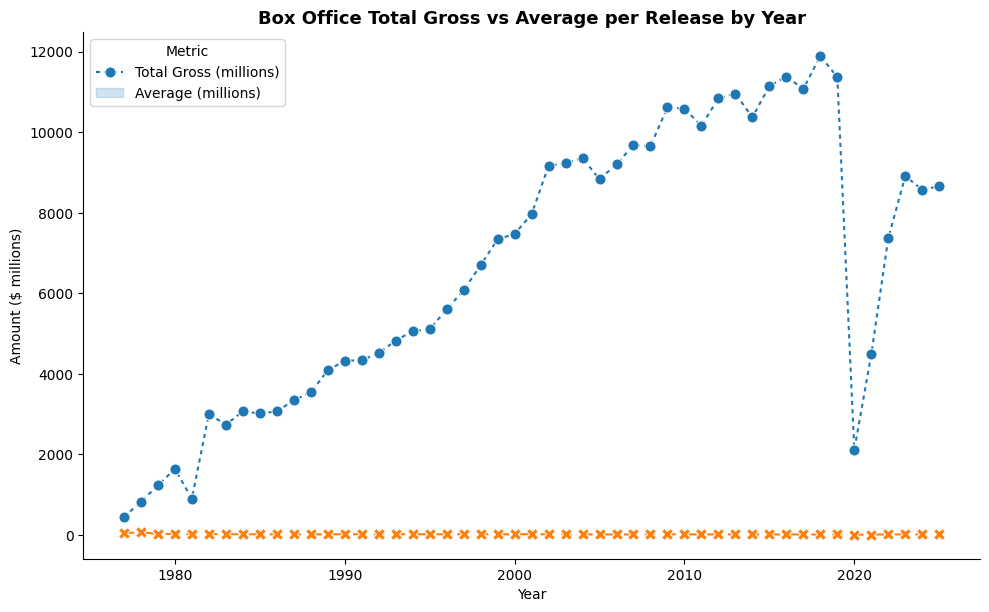

In [24]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=box_melted,
    x="year",
    y="value",
    hue="metric",
    style="metric",
    dashes={"total_gross_millions": (2, 2), "average_millions": (5, 5)},
    markers=True,
    markersize=8
)

sns.despine()
plt.tight_layout()
plt.xlabel("Year")
plt.ylabel("Amount ($ millions)")
plt.title("Box Office Total Gross vs Average per Release by Year",
          fontsize=13, fontweight="bold")
plt.legend(
    title="Metric",
    labels=["Total Gross (millions)", "Average (millions)"]
)
plt.show()

Reviewing this chart we can see a steep decline in total revenue in 2020 rebounding in from 2021 to 2023. Based on world events we can infer this was due to the global pandemic.

- Doing a bit of investigation I was able to find the source of the 1981 revenue decline was due to high profile box office flops including Heavens Gate a movie featuring Jeff Brides, Willem Dafoe, and Christopher Walken.